## **Librería pandas**

In [317]:
import pandas as pd

## **Extracción de datos**

In [318]:
datos = pd.read_csv('/content/datos_tratados.csv')

In [319]:
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


## **Exploración de datos**

In [320]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## **Limpieza de datos**

In [321]:
datos = datos.drop(columns=['CustomerID'])

In [322]:
datos.head(10)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
5,No,Female,No,No,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),2.31,69.40,571.45
6,No,Female,Yes,Yes,No,71,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),3.66,109.70,7904.25
7,No,Male,No,Yes,No,63,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,Yes,Credit card (automatic),2.82,84.65,5377.80
8,No,Female,Yes,No,No,7,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,1.61,48.20,340.35
9,No,Female,No,Yes,Yes,65,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Mailed check,3.02,90.45,5957.90


In [323]:
columnas_dos = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_dos:
  datos[col] = datos[col].replace('No internet service', 'No')

In [324]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **Análisis exploratorio**

In [325]:
datos_numericos = datos.select_dtypes(include=['int64', 'float64'])
datos_numericos['Churn'] = datos['Churn'].map({'Yes': 1, 'No': 0})
correlacion = datos_numericos.corr()

In [326]:
correlacion

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn
Tenure,1.000000,0.247910,0.247900,0.826178,-0.352229
ChargesDaily,0.247910,1.000000,0.999996,0.651189,0.193412
ChargesMonthly,0.247900,0.999996,1.000000,0.651174,0.193356
ChargesTotal,0.826178,0.651189,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193412,0.193356,-0.198324,1.000000


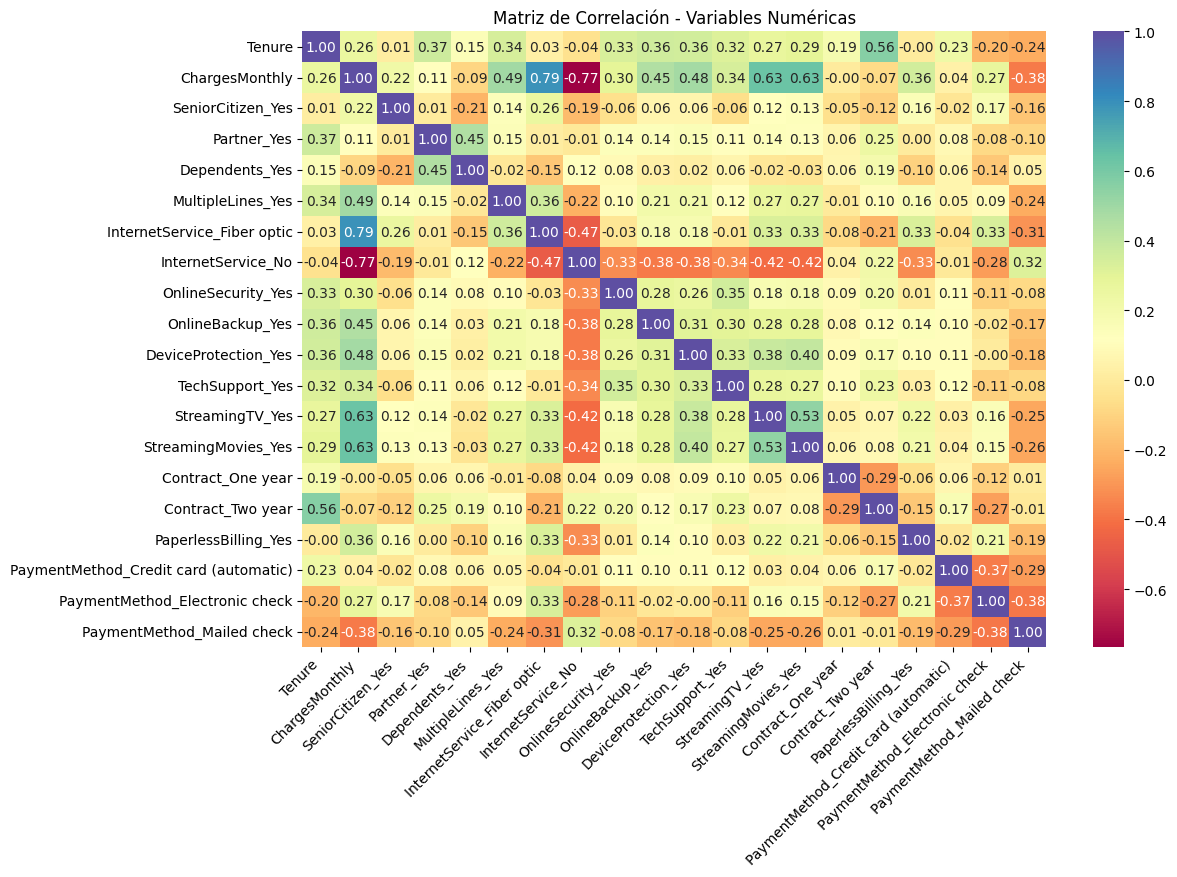

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="Spectral")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [328]:
datos = datos.drop(columns=['ChargesDaily', 'ChargesTotal'])

In [329]:
columnas_cat = datos.select_dtypes(include=['object']).columns
columnas_cat = columnas_cat.drop('Churn')
columnas_cat

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [330]:
for col in columnas_cat:
  print(f'Analisis de la variable {col}')
  display(pd.crosstab(datos[col], datos['Churn'], normalize='index')* 100)

Analisis de la variable Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Analisis de la variable SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


Analisis de la variable Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Analisis de la variable PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


Analisis de la variable PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## **Transformación de variables categóricas**

In [331]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [332]:
datos_copia = datos.copy()
datos_copia.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


In [333]:
datos_copia['Churn'] = datos_copia['Churn'].map({'Yes':1,'No':0})

In [334]:
columnas_cat = datos_copia.select_dtypes(include=['object']).columns

In [335]:
label_encoding = LabelEncoder()
for col in columnas_cat:
  datos_copia[col] = label_encoding.fit_transform(datos_copia[col])

X_cat = datos_copia[columnas_cat]
y = datos_copia["Churn"]

chi, p = chi2(X_cat, y)
chi = pd.DataFrame({
    'Variable': columnas_cat,
    'Chi2 Score': chi,
    'valor de p': p
})
chi = chi.sort_values(by="Chi2 Score", ascending=False)

chi

,Variable,Chi2 Score,valor de p
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [336]:
datos = datos.drop(columns=["Gender", "PhoneService"])

## **Preparación de los datos para el modelo**

In [337]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [338]:
from sklearn.model_selection import train_test_split

In [339]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [340]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test, = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5609,14,76.45,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False
2209,5,70.00,False,False,False,False,False,False,False,False,True,False,True,True,True,False,True,False,False,True
6919,35,75.20,False,True,False,True,True,False,False,False,False,False,False,False,False,False,True,False,True,False
2284,58,86.10,False,True,False,True,False,False,True,True,True,False,True,True,False,True,True,False,True,False
845,2,49.60,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True


In [341]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5609 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 4930 non-null   int64  
 1   ChargesMonthly                         4930 non-null   float64
 2   SeniorCitizen_Yes                      4930 non-null   bool   
 3   Partner_Yes                            4930 non-null   bool   
 4   Dependents_Yes                         4930 non-null   bool   
 5   MultipleLines_Yes                      4930 non-null   bool   
 6   InternetService_Fiber optic            4930 non-null   bool   
 7   InternetService_No                     4930 non-null   bool   
 8   OnlineSecurity_Yes                     4930 non-null   bool   
 9   OnlineBackup_Yes                       4930 non-null   bool   
 10  DeviceProtection_Yes                   4930 non-null   bool   
 11  TechSu

In [342]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2113 entries, 4839 to 341
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 2113 non-null   int64  
 1   ChargesMonthly                         2113 non-null   float64
 2   SeniorCitizen_Yes                      2113 non-null   bool   
 3   Partner_Yes                            2113 non-null   bool   
 4   Dependents_Yes                         2113 non-null   bool   
 5   MultipleLines_Yes                      2113 non-null   bool   
 6   InternetService_Fiber optic            2113 non-null   bool   
 7   InternetService_No                     2113 non-null   bool   
 8   OnlineSecurity_Yes                     2113 non-null   bool   
 9   OnlineBackup_Yes                       2113 non-null   bool   
 10  DeviceProtection_Yes                   2113 non-null   bool   
 11  TechSup

In [343]:
(y_train.value_counts(normalize=True)*100).round(2)

,proportion
Churn,
No,73.47
Yes,26.53


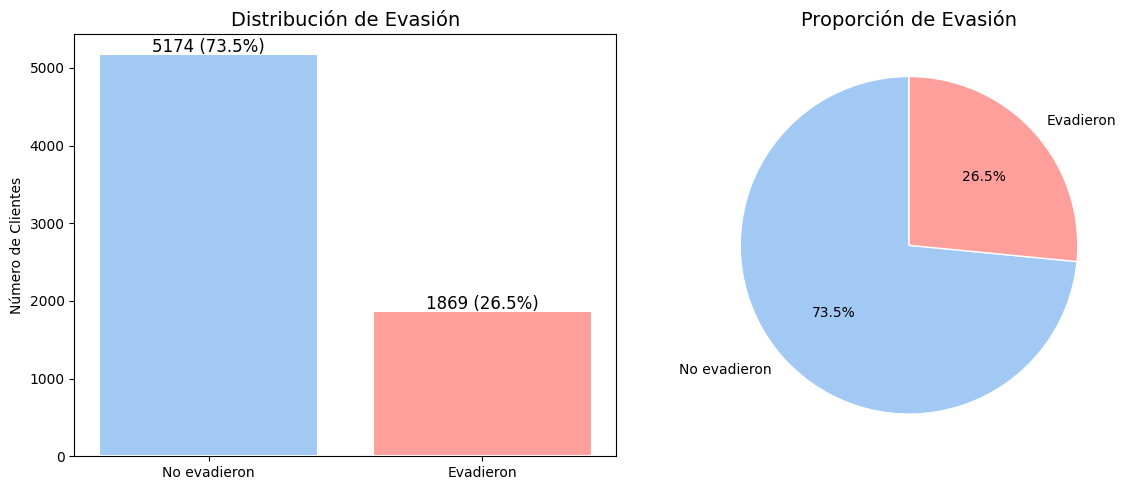

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns

cuenta_churn = y.value_counts()
porcentaje_churn = (y.value_counts(normalize=True) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
paleta = sns.color_palette('pastel')
barras = axes[0].bar(['No evadieron', 'Evadieron'], cuenta_churn.values,
                     color=[paleta[0], paleta[3]], edgecolor='white', linewidth=1.5)

for barra, cantidad, porcentaje in zip(barras, cuenta_churn.values, porcentaje_churn.values):
    axes[0].text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 30,
                 f'{cantidad} ({porcentaje:.1f}%)', ha='center', fontsize=12)

axes[0].set_title('Distribución de Evasión', fontsize=14)
axes[0].set_ylabel('Número de Clientes')
axes[1].pie(cuenta_churn.values, labels=['No evadieron', 'Evadieron'],
            autopct='%1.1f%%', startangle=90, colors=[paleta[0], paleta[3]], wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de Evasión', fontsize=14)

plt.tight_layout()
plt.show()

## **Balanceo con SMOTE**

In [345]:
from imblearn.over_sampling import SMOTE

In [346]:
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('Antes de SMOTE:')
print(y_train.value_counts())

print('\nDespués de SMOTE:')
print(y_train_res.value_counts())

Antes de SMOTE:
Churn
No     3622
Yes    1308
Name: count, dtype: int64

Después de SMOTE:
Churn
No     3622
Yes    3622
Name: count, dtype: int64


In [347]:
from sklearn.preprocessing import StandardScaler

In [348]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Matriz de Correlación**

In [349]:
import numpy as np

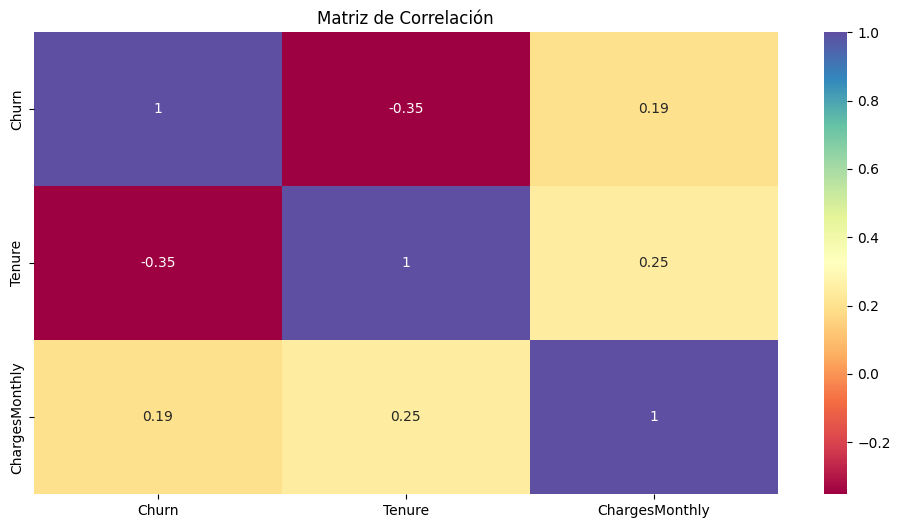

In [350]:
plt.figure(figsize=(12,6))

temp_datos_corr = datos.copy()
temp_datos_corr['Churn'] = temp_datos_corr['Churn'].map({'Yes': 1, 'No': 0})
correlacion = temp_datos_corr.select_dtypes(include=['number']).corr()

sns.heatmap(correlacion, cmap='Spectral', annot=True)
plt.title('Matriz de Correlación')
plt.show()

In [351]:
datos_train = X_train.copy()
datos_train['Churn'] = y_train

In [352]:
correlacion = X_train.copy()
correlacion['Churn'] = y_train
correlacion = correlacion.corr(numeric_only=True)

In [353]:
datos_train_numerico = datos_train.copy()
datos_train_numerico['Churn'] = datos_train_numerico['Churn'].map({'Yes': 1, 'No': 0})

In [354]:
corr_con_churn = datos_train_numerico.corr()
corr_churn = corr_con_churn['Churn'].drop('Churn').sort_values(ascending=False)

## **Figuras de Correlación y Densidad**

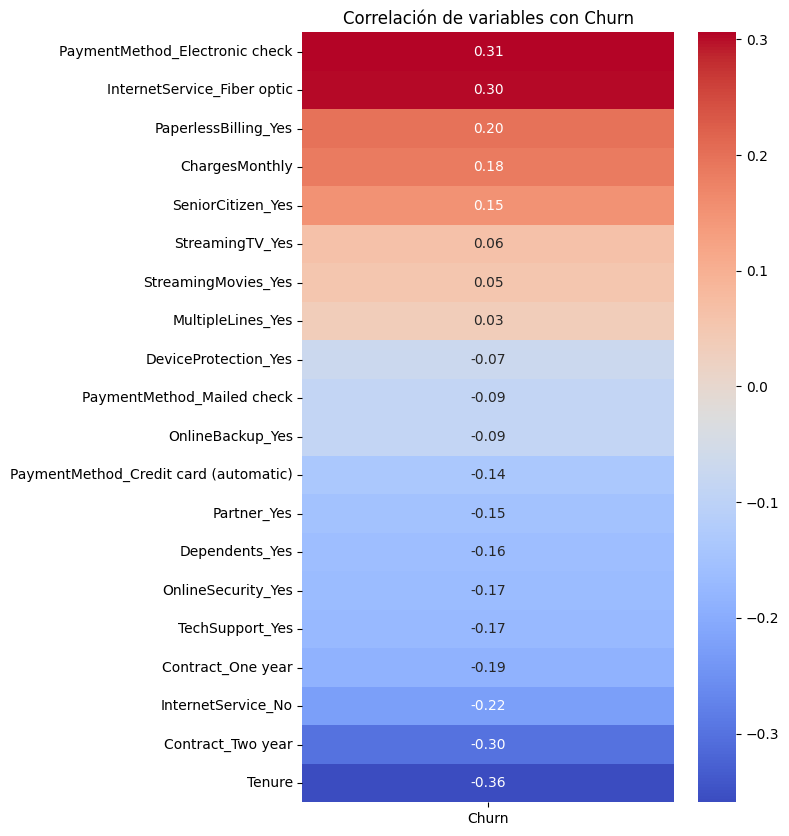

In [355]:
plt.figure(figsize=(6,10))

sns.heatmap(
    corr_churn.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlación de variables con Churn")

plt.show()

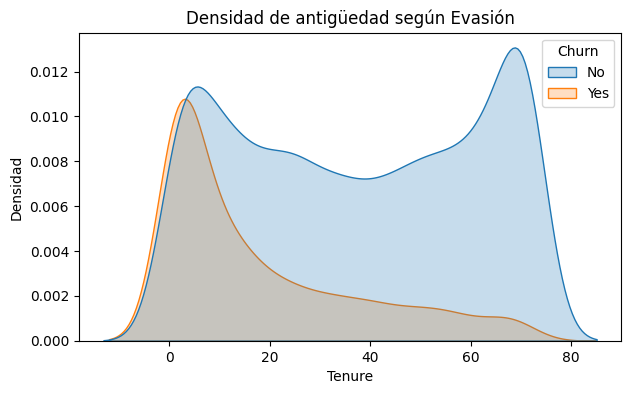

In [380]:
plt.figure(figsize=(7,4))

sns.kdeplot(data=datos, x='Tenure', hue='Churn', fill=True)

plt.title('Densidad de antigüedad según Evasión')
plt.ylabel('Densidad')
plt.show()

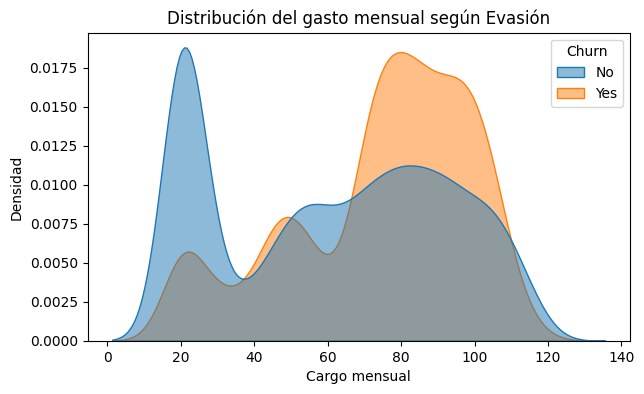

In [357]:
plt.figure(figsize=(7,4))

sns.kdeplot(
    data=datos,
    x='ChargesMonthly',
    hue='Churn',
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title('Distribución del gasto mensual según Evasión')
plt.xlabel('Cargo mensual')
plt.ylabel('Densidad')

plt.show()

In [358]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## **Construcción de modelos**

## **Modelo de Regresión Logística**

In [359]:
modelo_logico = LogisticRegression(max_iter=1000)
modelo_logico.fit(X_train, y_train)
y_pred_logico = modelo_logico.predict(X_test)
print('Modelo de Regresión Logística')
print(classification_report(y_test, y_pred_logico))

Modelo de Regresión Logística
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1552
         Yes       0.64      0.54      0.58       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



## **Modelo de Random Forest**

In [360]:
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train,y_train)
y_pred_random_forest = random_forest.predict(X_test)
print('Modelo de Random Forest')
print(classification_report(y_test, y_pred_random_forest))

Modelo de Random Forest
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1552
         Yes       0.61      0.48      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.70      2113
weighted avg       0.77      0.78      0.77      2113



In [361]:
arbol_decision = DecisionTreeClassifier(random_state=42)
arbol_decision.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [362]:
y_pred_arbol_decision = arbol_decision.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred_arbol_decision))
print('Precision:', precision_score(y_test, y_pred_arbol_decision, pos_label='Yes'))
print('Recall:', recall_score(y_test, y_pred_arbol_decision, pos_label='Yes'))
print('F1 Score:', f1_score(y_test, y_pred_arbol_decision, pos_label='Yes'))

Accuracy: 0.7255087553241836
Precision: 0.48353552859618715
Recall: 0.49732620320855614
F1 Score: 0.4903339191564148


In [363]:
modelos = {
    "Regresión Logística": y_pred_logico,
    "Random Forest": y_pred_random_forest,
    "Árbol de decisión": y_pred_arbol_decision
}

resultados = []

for nombre, pred in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precisión": precision_score(y_test, pred, pos_label='Yes'),
        "Recall": recall_score(y_test, pred, pos_label='Yes'),
        "F1 Score": f1_score(y_test, pred, pos_label='Yes')
    })

resultados = pd.DataFrame(resultados)

resultados

,Modelo,Accuracy,Precisión,Recall,F1 Score
0,Regresión Logística,0.796025,0.636555,0.540107,0.584378
1,Random Forest,0.778987,0.605856,0.479501,0.535323
2,Árbol de decisión,0.725509,0.483536,0.497326,0.490334


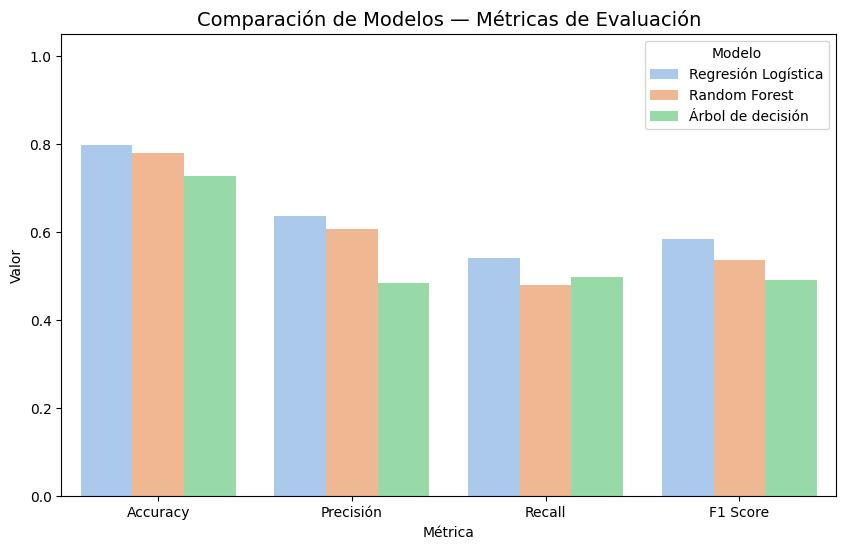

In [384]:
df_melt = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x='Métrica', y='Valor', hue='Modelo', palette='pastel')

plt.title('Comparación de Modelos — Métricas de Evaluación', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Modelo')
plt.ylabel('Valor')
plt.show()

## **Mejor modelo**

In [364]:
resultados.sort_values(by='Recall', ascending=False)

,Modelo,Accuracy,Precisión,Recall,F1 Score
0,Regresión Logística,0.796025,0.636555,0.540107,0.584378
2,Árbol de decisión,0.725509,0.483536,0.497326,0.490334
1,Random Forest,0.778987,0.605856,0.479501,0.535323


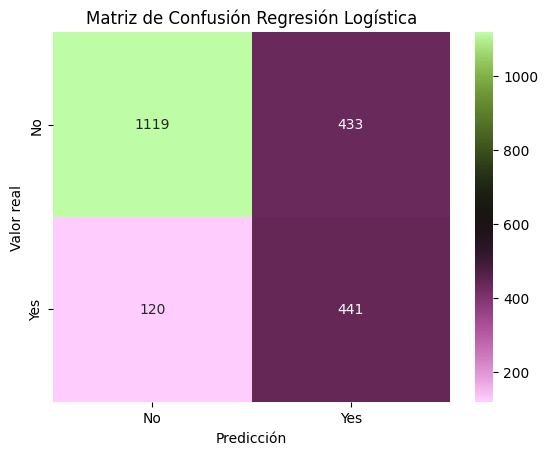

In [365]:
from sklearn.metrics import ConfusionMatrixDisplay

modelo_champion = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

modelo_champion.fit(X_train, y_train)

y_pred_final = modelo_champion.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="vanimo",
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.title('Matriz de Confusión Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.show()

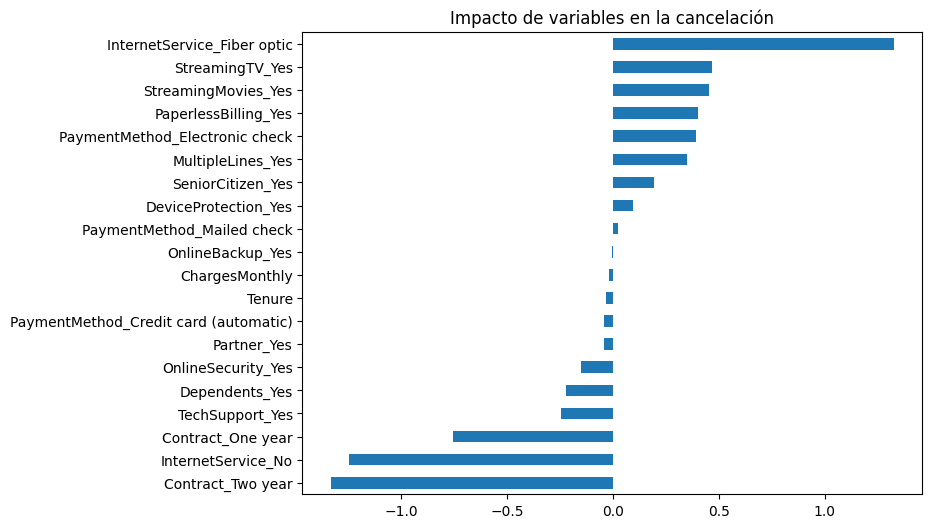

In [366]:
coeficientes = pd.Series(
    modelo_champion.coef_[0],
    index=X_train.columns
).sort_values(ascending=False)

coeficientes.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Impacto de variables en la cancelación")
plt.show()

## **Descargar modelo**

In [385]:
import pickle
from google.colab import files

with open("modelo_champion.pkl", "wb") as archivo:
    pickle.dump(modelo_logico, archivo)

print("Modelo guardado correctamente")
files.download("modelo_champion.pkl")

Modelo guardado correctamente


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Informe Final**

El objetivo de este análisis fue conocer los factores que más influyen en la cancelación o evasión de clientes, visto en todo el análisis como "Churn" en la empresa.

Y lo más importante: desarrollar modelos que nos ayuden a predecir clientes con alto riesgo de cancelar el servicio

Para realizar lo anterior mencionado se tuvieron que preparar los datos, usando el One-Hot Encoding para evitar la multicolinealidad.

Dentro de las **correlaciones** más claves podemos observar lo siguiente:
- La antigüedad (tenure) tiene una correlación con Churn (-0.36) lo que indica que a mayor antigüedad, menor riesgo de cancelar
- ChargesMonthly tiene una correlacion positiva (0.18) lo que indica que cargos mensuales altos se puede asociar a mayor evasión

**Comparación de modelos**
- Regresión Logística - Random Forest - Árbol de Decisión
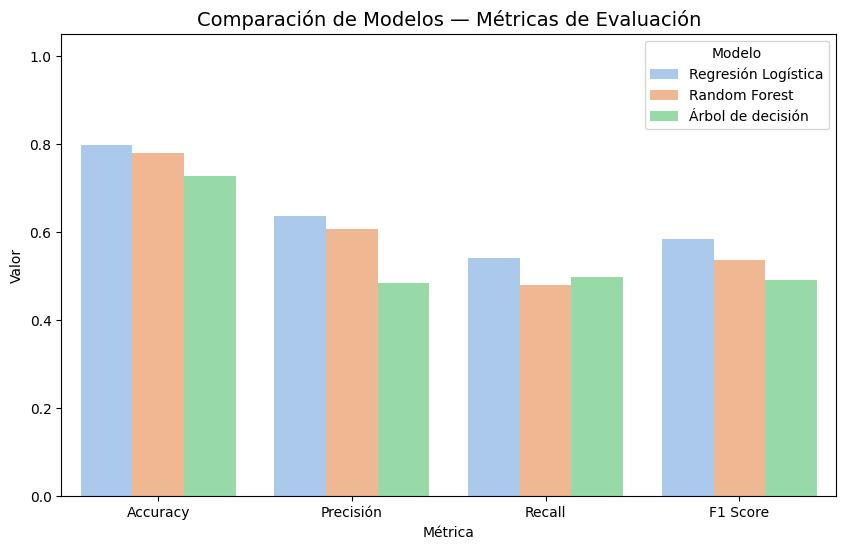

En todos y cada uno de las características supera Regresión Logística (en exactitud, precision, recall, **f1 score**)


## **Modelo Campeón: Modelo de Regresión Logística**


## **Factores que influyen en la cancelación**

Los principales factores asociados con la cancelación de clientes son:

- Clientes con poco tiempo en la empresa
- Clientes con cargos mensuales elevados
- Clientes con contratos mensuales en lugar de contratos de largo plazo


## **Estrategias**

- Intencivos para firmar contratos de una mayor duración, superando los primeros 12 meses
- Los clientes que hacen sus temas por cheque electrónico muestra alta tasa de cancelación, deben migrarse a pagos con tarjeta o transferencia bancaria

## **Conclusión**
Como se puede analizar en este proyecto/challenge el uso de machine learning ayuda y permite identificar algunos patrones en el comportamiento, anticiparlas y realizar estrategias trae muchos beneficios y ventajas competitivas a las organizaciones.